# DataScience excercise-02-Descriptive Analysis

### DATASET : IMDB TOP 1000 MOVIES

In [1]:
import pandas as pd
import numpy as np

#### 00-Load Data as dataframe

In [2]:
df = pd.read_csv("archive/imdb_top_1000.csv")

#### 01-DATASET Dimensions

In [3]:
print("DATASET DIMENSIONS\n")
print(f"Dataset Shape:\n {df.shape[0]} rows (movies) x {df.shape[1]} columns(features)")
print(f"\nfeatures : ")
print(df.columns)

DATASET DIMENSIONS

Dataset Shape:
 1000 rows (movies) x 16 columns(features)

features : 
Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')


In [4]:
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


#### 02-Data types and missing values

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [6]:
df.isnull().sum()

Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

#### 02.2-Data type conversion

In [7]:
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce').astype('Int64')

In [8]:
df['Runtime'] = df['Runtime'].str.replace(' min', '', regex=False)
df['Runtime'] = pd.to_numeric(df['Runtime'], errors='coerce')

In [9]:
df['Gross'] = df['Gross'].str.replace(',', '', regex=False)
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')

In [10]:
df.dtypes

Poster_Link       object
Series_Title      object
Released_Year      Int64
Certificate       object
Runtime            int64
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross            float64
dtype: object

#### 03-Describe dataset with statistics

In [11]:
df.describe()

,Released_Year,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross
count,999.0,1000.000000,1000.000000,843.000000,1.000000e+03,8.310000e+02
mean,1991.217217,122.891000,7.949300,77.971530,2.736929e+05,6.803475e+07
std,23.297025,28.093671,0.275491,12.376099,3.273727e+05,1.097500e+08
min,1920.0,45.000000,7.600000,28.000000,2.508800e+04,1.305000e+03
25%,1976.0,103.000000,7.700000,70.000000,5.552625e+04,3.253559e+06
50%,1999.0,119.000000,7.900000,79.000000,1.385485e+05,2.353089e+07
75%,2009.0,137.000000,8.100000,87.000000,3.741612e+05,8.075089e+07
max,2020.0,321.000000,9.300000,100.000000,2.343110e+06,9.366622e+08


In [12]:
numeric_cols = ['Released_Year','IMDB_Rating', 'Runtime', 'Meta_score', 'No_of_Votes', 'Gross']

In [13]:
mean = df[numeric_cols].mean()
median = df[numeric_cols].median()
mode = df[numeric_cols].mode().iloc[0]
std = df[numeric_cols].std()
quartiles = df[numeric_cols].quantile([0.25, 0.5, 0.75])
range_vals = df[numeric_cols].max() - df[numeric_cols].min()

In [14]:
print("Mean -------------------------\n")
print(mean)
print("\nMedian -------------------------\n")
print(median)
print("\nMode -------------------------\n")
print(mode)
print("\nStd -------------------------\n")
print(std)
print("\nquartiles -------------------------\n")
print(quartiles)
print("\nrange_vals -------------------------\n")
print(range_vals)

Mean -------------------------

Released_Year        1991.217217
IMDB_Rating               7.9493
Runtime                  122.891
Meta_score              77.97153
No_of_Votes           273692.911
Gross            68034750.873646
dtype: Float64

Median -------------------------

Released_Year        1999.0
IMDB_Rating             7.9
Runtime               119.0
Meta_score             79.0
No_of_Votes        138548.5
Gross            23530892.0
dtype: Float64

Mode -------------------------

Released_Year       2014.0
IMDB_Rating            7.7
Runtime              100.0
Meta_score            76.0
No_of_Votes        65341.0
Gross            4360000.0
Name: 0, dtype: Float64

Std -------------------------

Released_Year           23.297025
IMDB_Rating              0.275491
Runtime                 28.093671
Meta_score              12.376099
No_of_Votes         327372.703934
Gross            109750043.192185
dtype: Float64

quartiles -------------------------

      Released_Year  IMDB_Rat

#### 04-Categorical data
frequency and percentage

In [15]:
df.groupby('Certificate').size().sort_values(ascending=False)

Certificate
U           234
A           197
UA          175
R           146
PG-13        43
PG           37
Passed       34
G            12
Approved     11
TV-PG         3
GP            2
16            1
TV-MA         1
TV-14         1
U/A           1
Unrated       1
dtype: int64

In [16]:
categorical_cols = ['Certificate', 'Genre', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']

freq_tables = {}

for col in categorical_cols:
    freq = df.groupby(col).size().sort_values(ascending=False)   
    total_count = df.groupby(col).size().sum()
    percent = (freq / total_count) * 100 
     
    
    
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage': percent
    })
    
    freq_tables[col] = table


In [17]:
for col, table in freq_tables.items():
    print(f"\n=== {col} ===")
    display(table)


=== Certificate ===


,Frequency,Percentage
Certificate,,
U,234,26.028921
A,197,21.913237
UA,175,19.466073
R,146,16.240267
PG-13,43,4.783092
PG,37,4.115684
Passed,34,3.781980
G,12,1.334816
Approved,11,1.223582



=== Genre ===


,Frequency,Percentage
Genre,,
Drama,85,8.5
"Drama, Romance",37,3.7
"Comedy, Drama",35,3.5
"Comedy, Drama, Romance",31,3.1
"Action, Crime, Drama",30,3.0
...,...,...
"Film-Noir, Mystery",1,0.1
"Fantasy, Horror",1,0.1
"Fantasy, Horror, Mystery",1,0.1



=== Director ===


...

,Frequency,Percentage
Star2,,
Emma Watson,7,0.7
Matt Damon,5,0.5
Brad Pitt,4,0.4
Kate Winslet,4,0.4
Chris Evans,4,0.4
...,...,...
Irrfan Khan,1,0.1
Isabelle Adjani,1,0.1
Issey Takahashi,1,0.1



=== Star3 ===


,Frequency,Percentage
Star3,,
Rupert Grint,5,0.5
Carrie Fisher,4,0.4
John Goodman,4,0.4
Joe Pesci,4,0.4
Jennifer Connelly,4,0.4
...,...,...
In-mun Kim,1,0.1
Indraneil Sengupta,1,0.1
Inge Landgut,1,0.1



=== Star4 ===


,Frequency,Percentage
Star4,,
Michael Caine,4,0.4
Mark Ruffalo,3,0.3
Catherine Keener,3,0.3
Stellan Skarsgård,2,0.2
Takashi Shimura,2,0.2
...,...,...
Herbert Lom,1,0.1
Hiam Abbass,1,0.1
Ho-jin Chun,1,0.1


#### 05-Outliers

In [18]:
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col}: {outliers.shape[0]}")


Outliers in Released_Year: 7
Outliers in Runtime: 29
Outliers in IMDB_Rating: 13


Outliers in Meta_score: 7
Outliers in No_of_Votes: 67
Outliers in Gross: 89


#### 06- Visualization

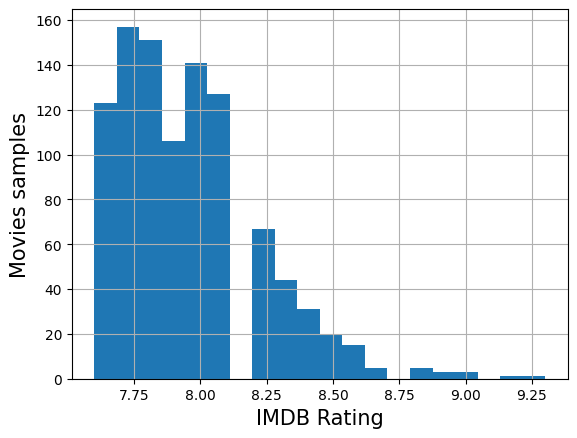

In [19]:
import matplotlib.pyplot as plt
df_rate=df['IMDB_Rating']
df_rate.hist(density=False, histtype='stepfilled', bins=20)

plt.xlabel('IMDB Rating',fontsize=15)
plt.ylabel('Movies samples',fontsize=15)
plt.show()

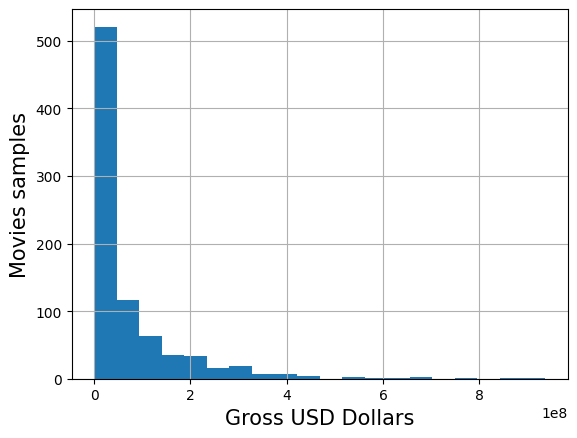

In [20]:
df_rate=df['Gross']
df_rate.hist(density=False, histtype='stepfilled', bins=20)

plt.xlabel('Gross USD Dollars',fontsize=15)
plt.ylabel('Movies samples',fontsize=15)
plt.show()

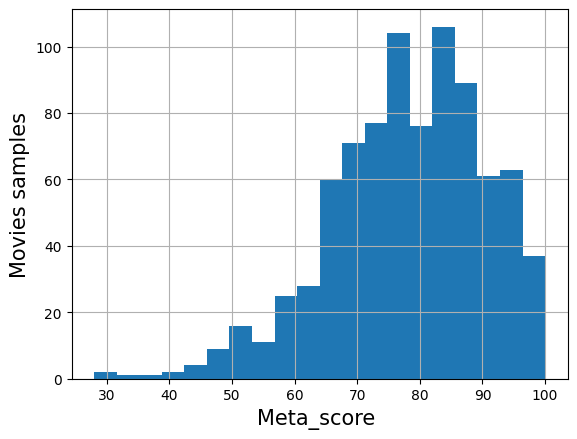

In [21]:
df_rate=df['Meta_score']
df_rate.hist(density=False, histtype='stepfilled', bins=20)

plt.xlabel('Meta_score ',fontsize=15)
plt.ylabel('Movies samples',fontsize=15)
plt.show()

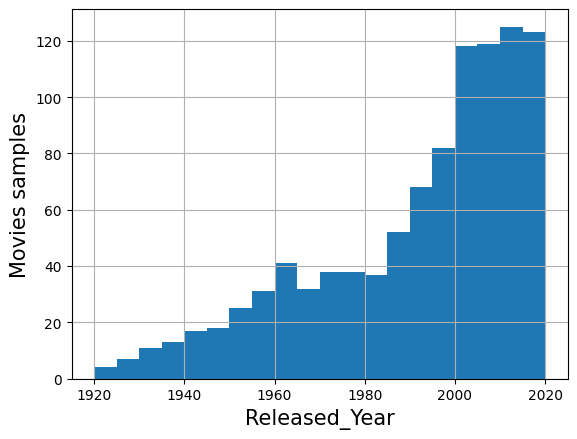

In [22]:
df_rate=df['Released_Year']
df_rate.hist(density=False, histtype='stepfilled', bins=20)

plt.xlabel('Released_Year',fontsize=15)
plt.ylabel('Movies samples',fontsize=15)
plt.show()

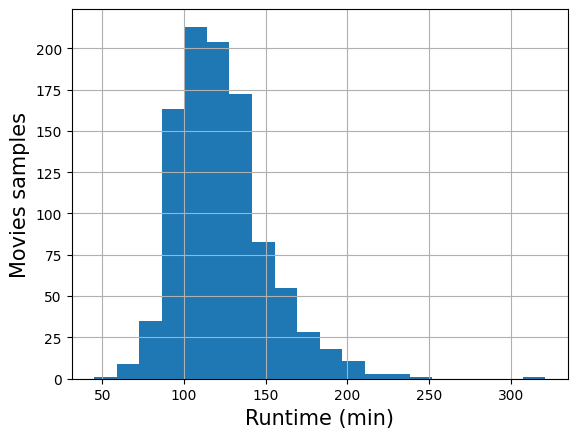

In [23]:
df_rate=df['Runtime']
df_rate.hist(density=False, histtype='stepfilled', bins=20)

plt.xlabel('Runtime (min)',fontsize=15)
plt.ylabel('Movies samples',fontsize=15)
plt.show()

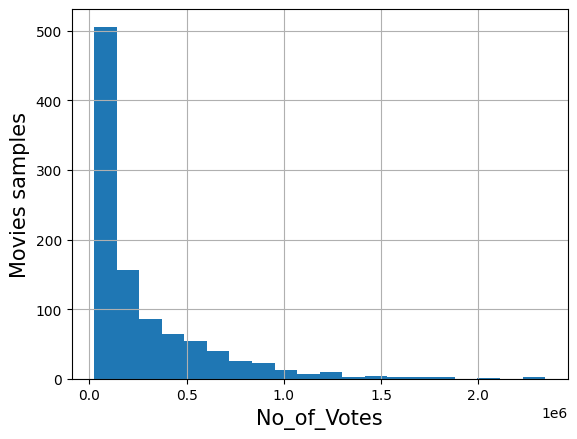

In [24]:
df_rate=df['No_of_Votes']
df_rate.hist(density=False, histtype='stepfilled', bins=20)

plt.xlabel('No_of_Votes',fontsize=15)
plt.ylabel('Movies samples',fontsize=15)
plt.show()

#### 06.1 Histograms (Probabilty and CDF)

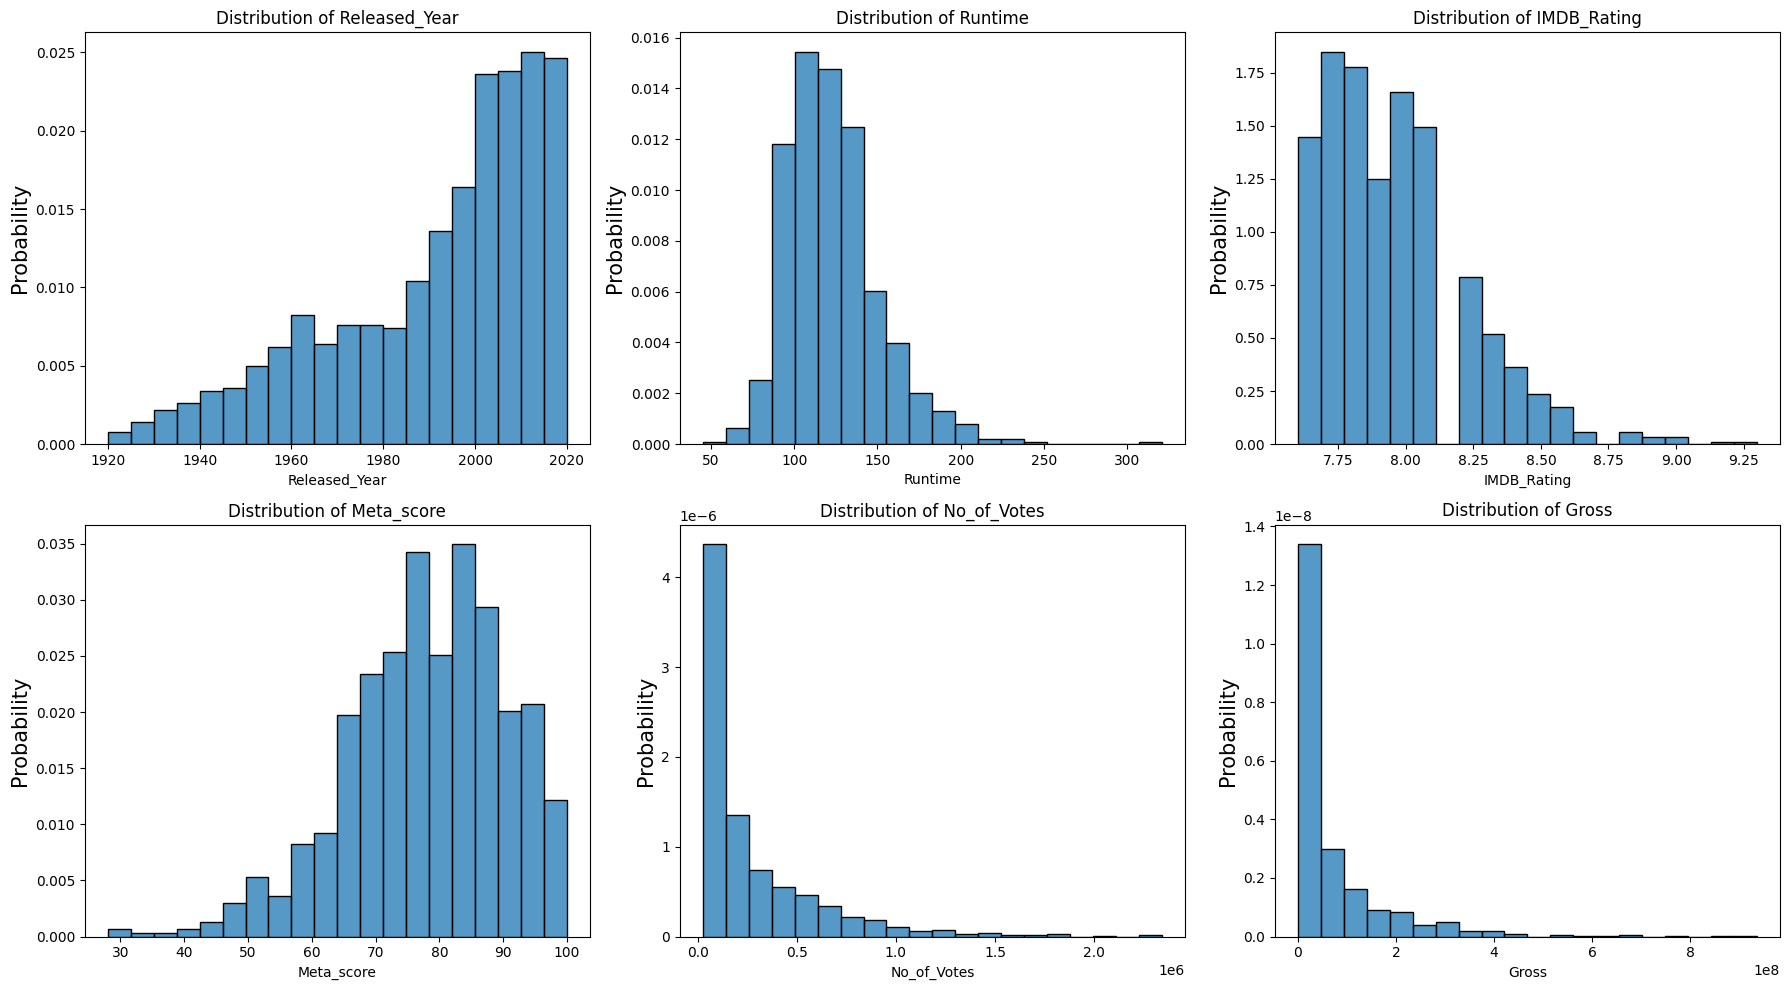

In [25]:
import seaborn as sns

cols = ['Released_Year', 'Runtime', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, ax=axes[i], 
                 kde=False, bins=20, stat='density', fill=True) 
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Probability', fontsize=15)

plt.tight_layout()
plt.show()


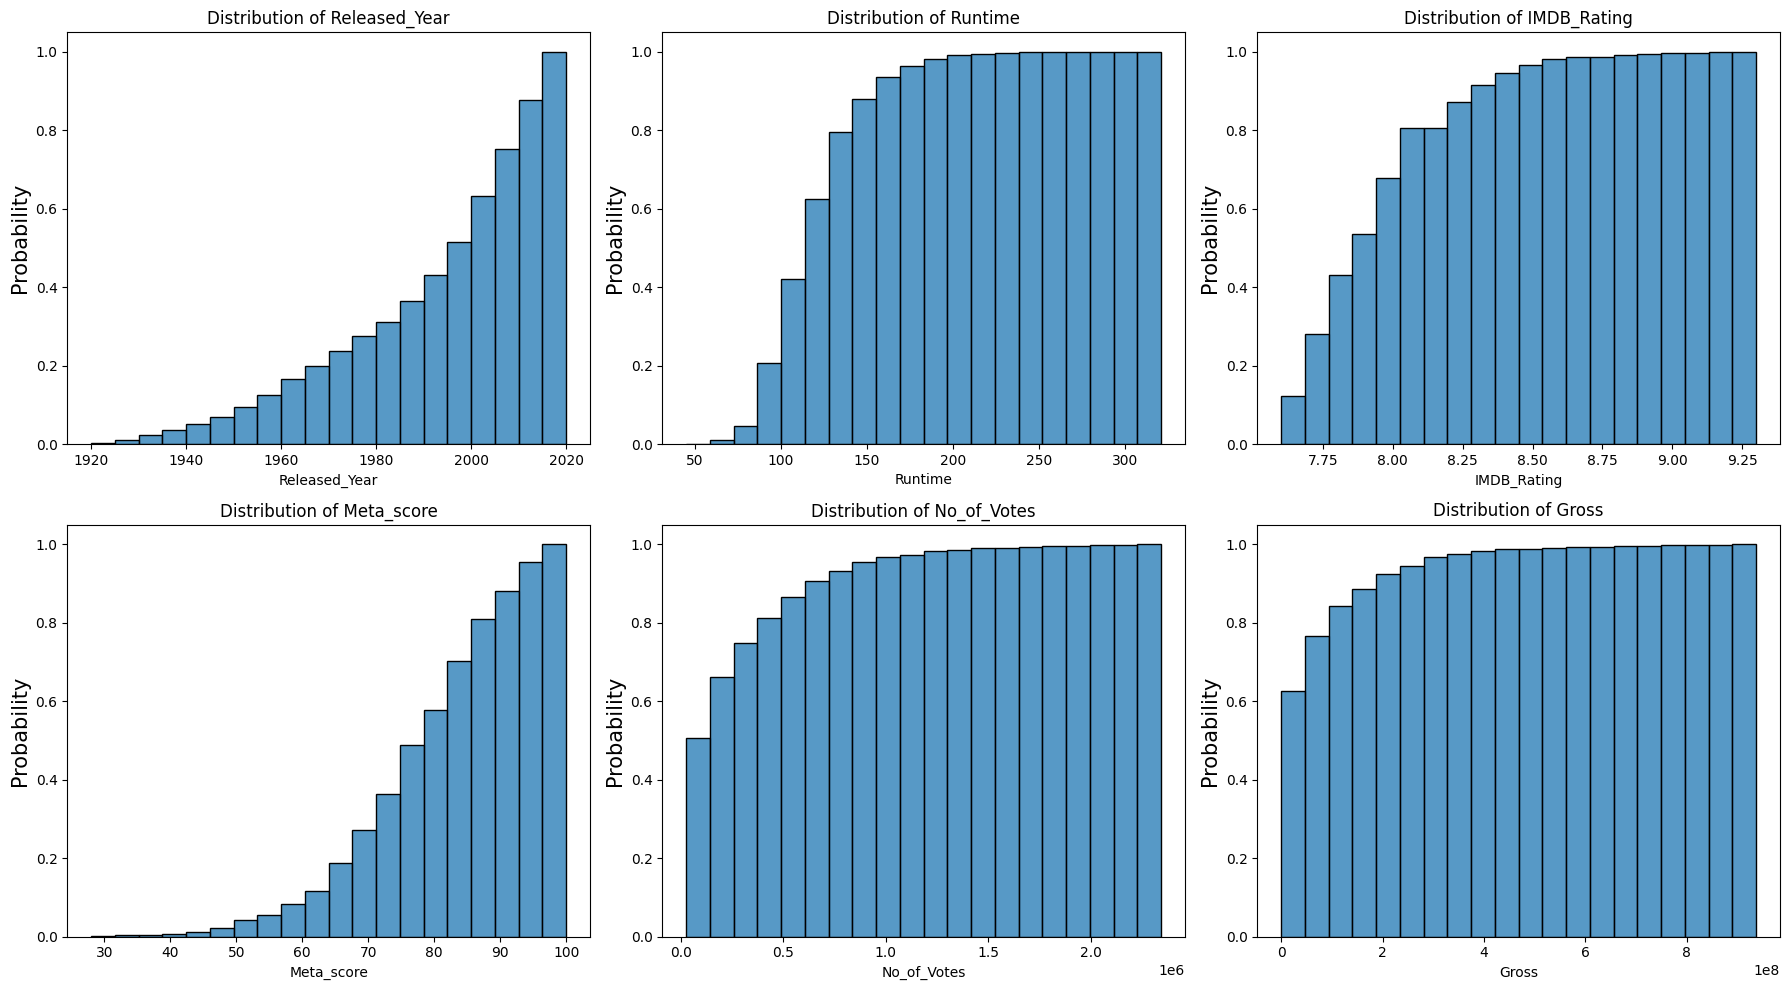

In [26]:
cols = ['Released_Year', 'Runtime', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, ax=axes[i], 
                 kde=False, bins=20, stat='density', fill=True, cumulative=True) 
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Probability', fontsize=15)

plt.tight_layout()
plt.show()

#### 06.2 Boxplot

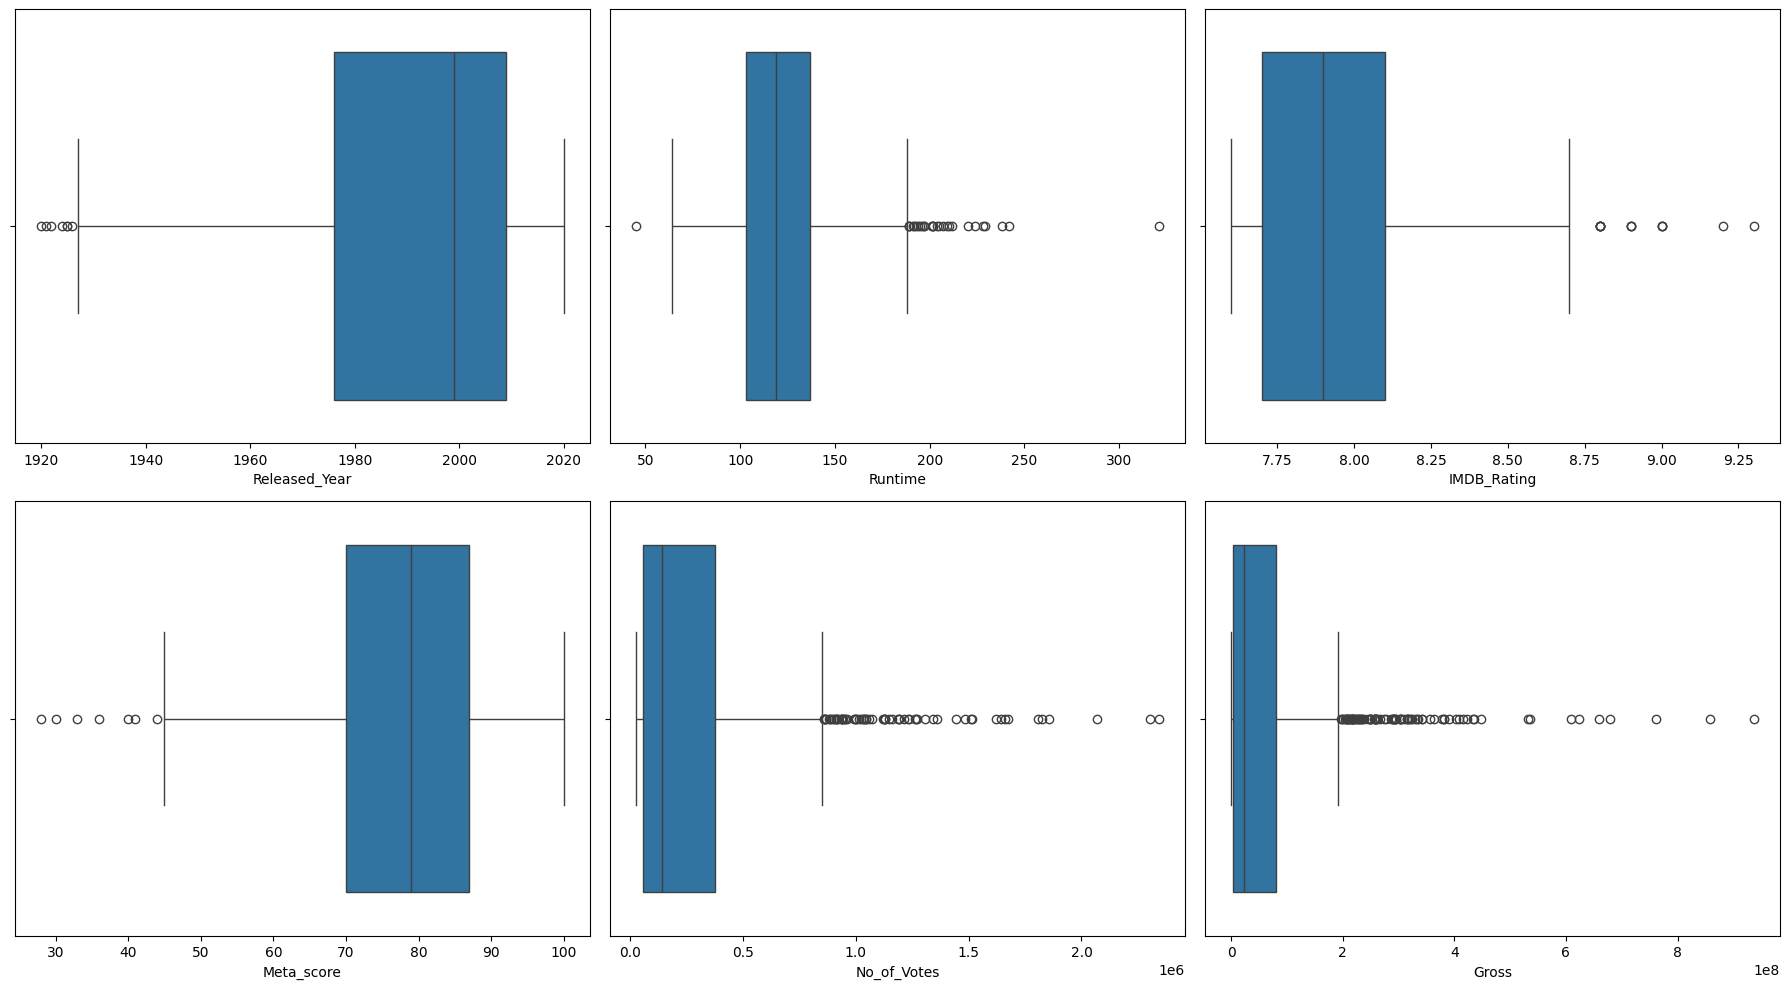

In [27]:
cols = ['Released_Year', 'Runtime', 'IMDB_Rating', 'Meta_score', 'No_of_Votes',
       'Gross']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax= axes[i])
plt.tight_layout()
plt.show()

#### 06.3 Scatterplot

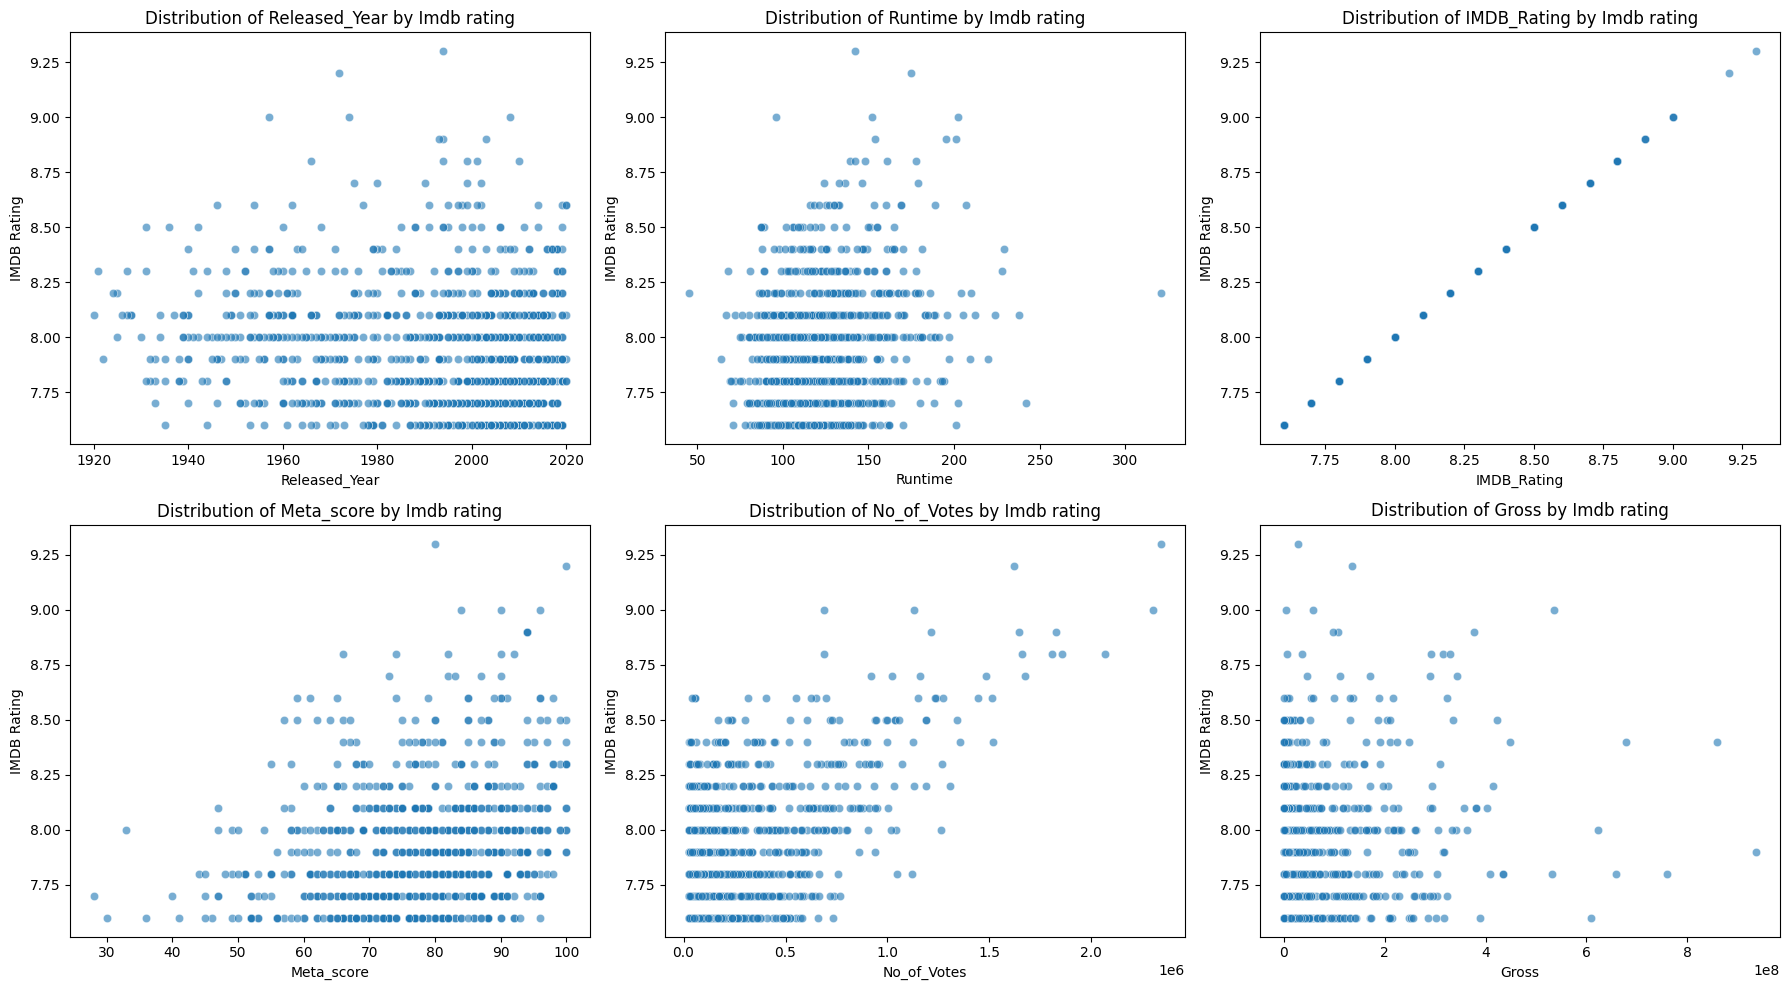

In [28]:
cols = ['Released_Year', 'Runtime', 'IMDB_Rating', 'Meta_score', 'No_of_Votes',
       'Gross']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.scatterplot(x=df[col], y=df["IMDB_Rating"], 
                    ax=axes[i], 
                    alpha=0.6) 

    axes[i].set_title(f"Distribution of {col} by Imdb rating")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("IMDB Rating")
plt.tight_layout()
plt.show()

<Axes: xlabel='Released_Year', ylabel='Gross'>

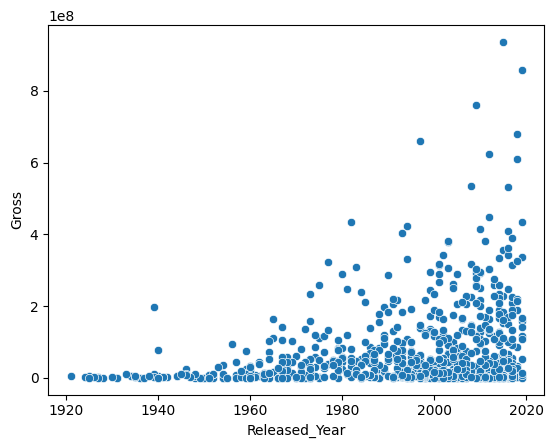

In [29]:
sns.scatterplot(x=df["Released_Year"], y=df["Gross"])

<Axes: xlabel='Runtime', ylabel='Gross'>

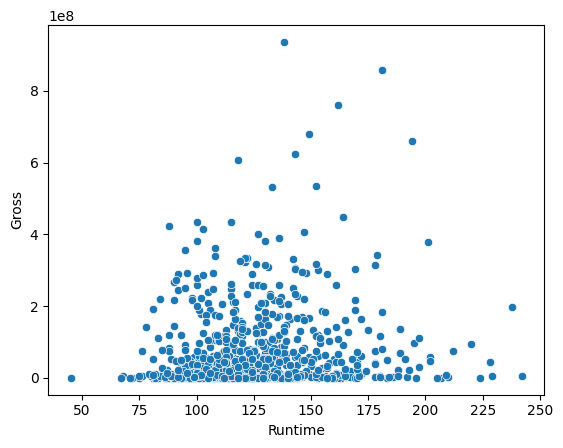

In [30]:
sns.scatterplot(x=df["Runtime"], y=df["Gross"])

<Axes: xlabel='Meta_score', ylabel='Gross'>

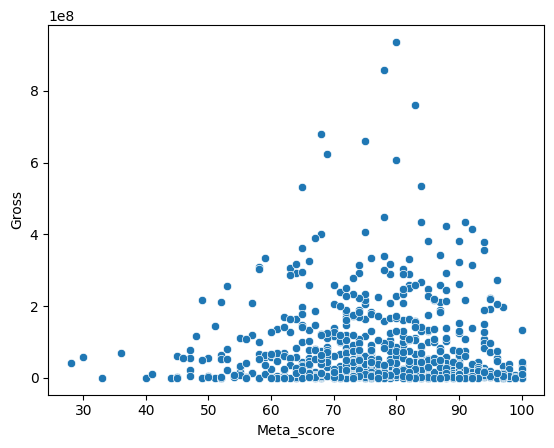

In [31]:
sns.scatterplot(x=df["Meta_score"], y=df["Gross"])

<Axes: xlabel='Released_Year', ylabel='No_of_Votes'>

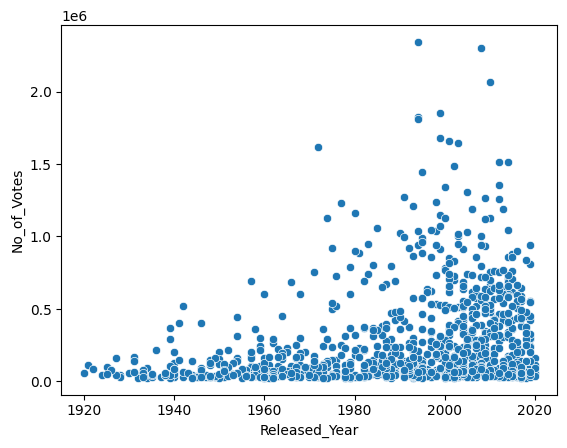

In [32]:
sns.scatterplot(x=df["Released_Year"], y=df["No_of_Votes"])

<Axes: xlabel='Released_Year', ylabel='Meta_score'>

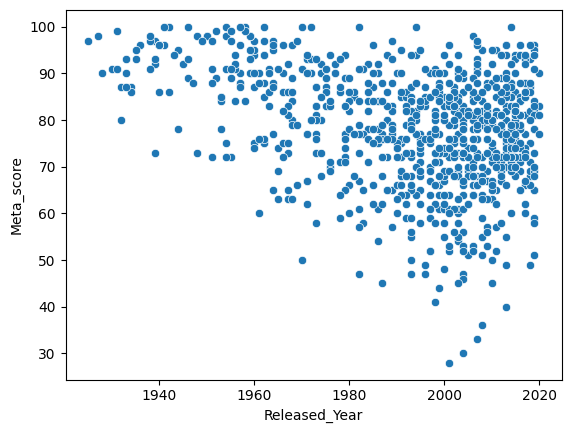

In [33]:
sns.scatterplot(x=df["Released_Year"], y=df["Meta_score"])

<Axes: xlabel='No_of_Votes', ylabel='Meta_score'>

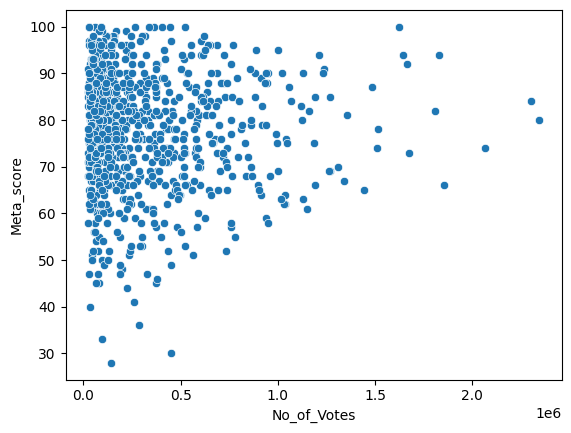

In [34]:
sns.scatterplot(x=df["No_of_Votes"], y=df["Meta_score"])

#### 06.4 Bar Plot (for categorical columns)

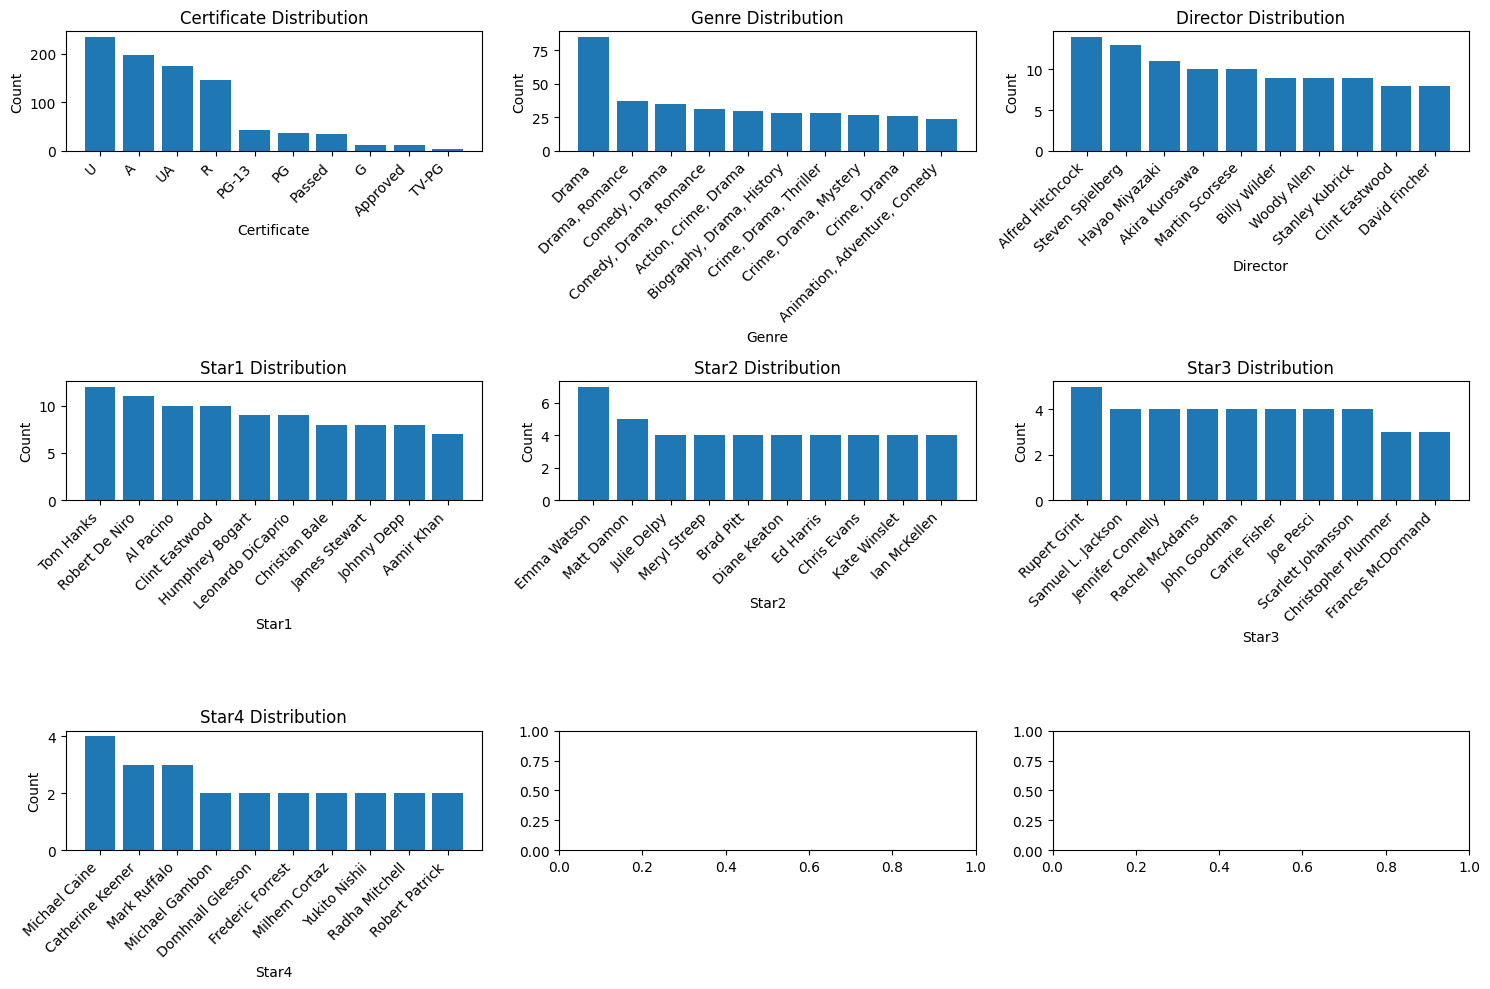

In [35]:
import matplotlib.pyplot as plt

categorical_cols = ['Certificate', 'Genre', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']

data_list = []
for col in categorical_cols:
    counts = df[col].value_counts().head(10).reset_index()
    counts.columns = [col, 'Count']
    data_list.append(counts)

rows, cols = 3, 3
total_plots = len(categorical_cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= total_plots:
        break
    
    col_name = categorical_cols[i]
    df_counts = data_list[i]  
    
    labels = df_counts[col_name] 
    values = df_counts['Count']
    
    ax.bar(range(len(values)), values)
    
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(labels, rotation=45, ha='right') 
    
    ax.set_xlabel(col_name)
    ax.set_ylabel('Count')
    ax.set_title(f'{col_name} Distribution')
    


plt.tight_layout()
plt.show()


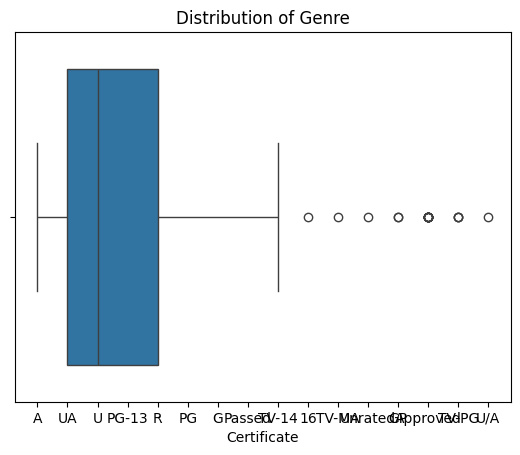

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.boxplot(x='Certificate', data=df)

plt.title('Distribution of Genre')
plt.show()


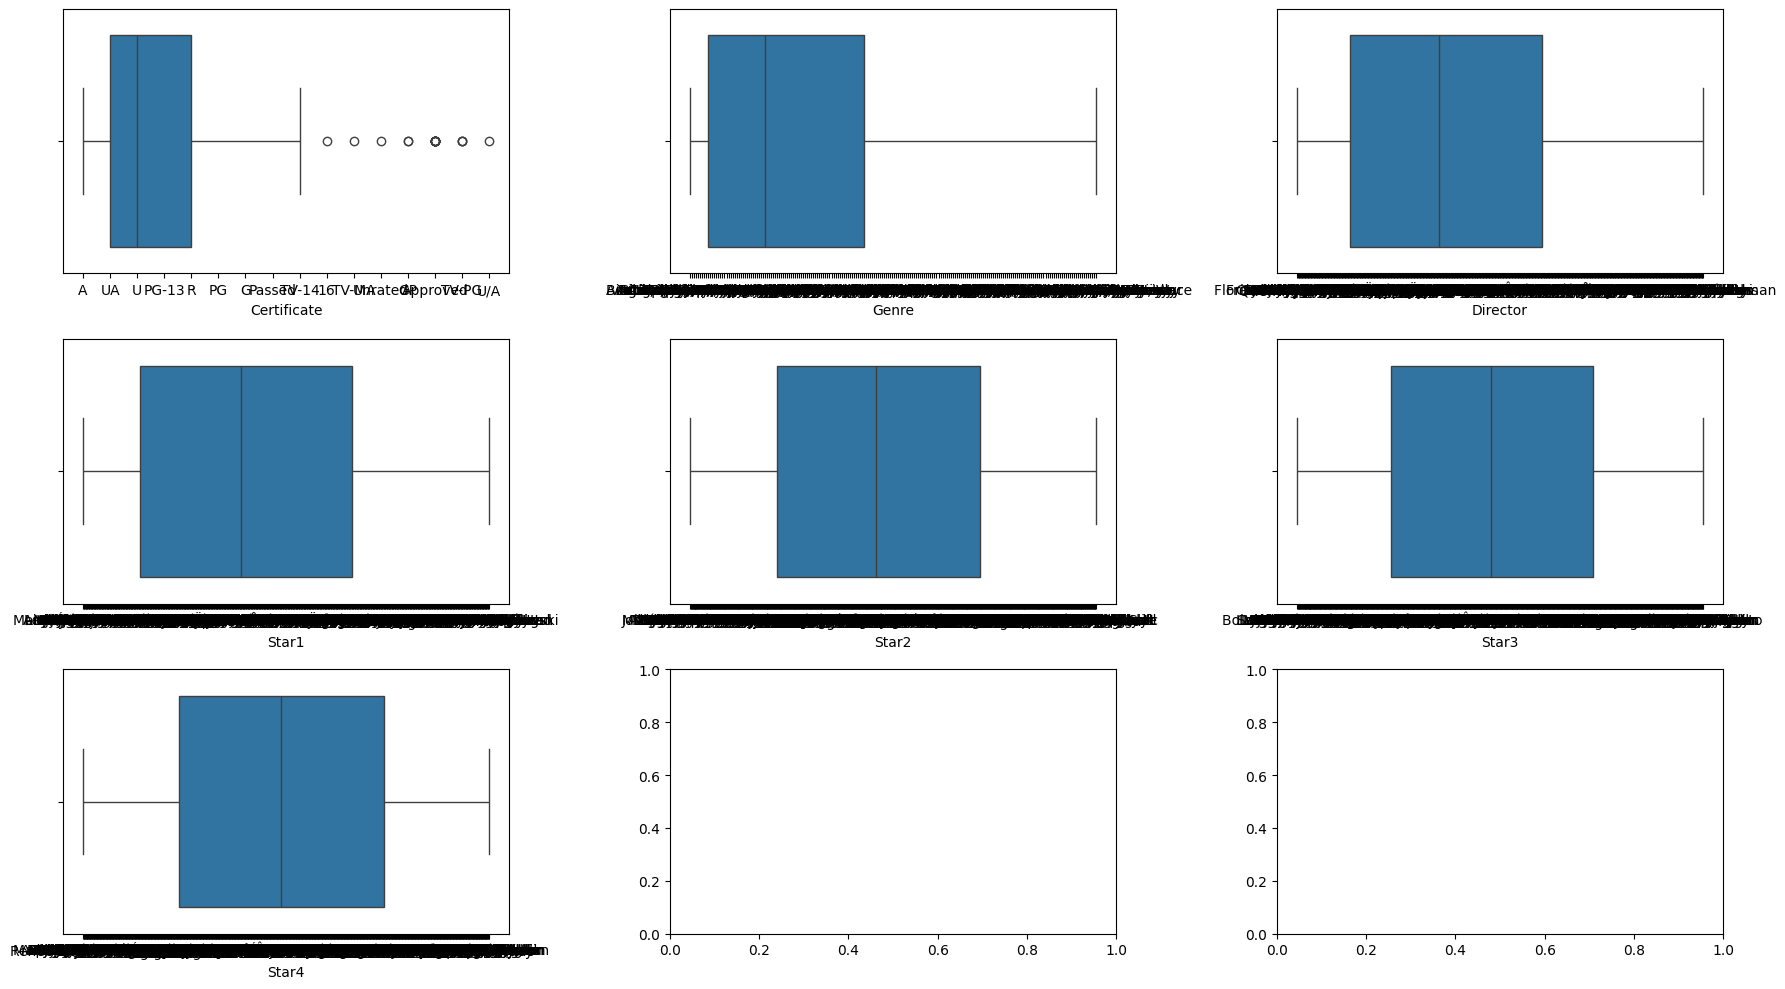

In [37]:
categorical_cols = ['Certificate', 'Genre', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.boxplot(x=col, data=df, ax = axes[i])
plt.tight_layout()
plt.show()